# **Case Study: Demand Forecasting for Apparel Retail Stores**

## Business Context

You are the Lead Data Scientist for a fast-scaling apparel retail company operating across India. The brand has over 200 stores spread across four major zones (North, South, East, and West), selling a range of apparel categories (e.g., Shirts, Trousers, Jackets, Dresses, and Accessories).

Over the past year, the company has faced challenges with stockouts in some stores and overstocking in others. This has resulted in lost sales opportunities in high-demand regions and increased markdown/clearance costs in low-demand areas.

Management has asked you to develop a demand forecasting framework that considers zone-level trends, seasonal variations, and category-specific dynamics to inform store replenishment and buying strategies.

## Problem Statement

Your task is to:

- Forecast demand for apparel categories across different zones for the next quarter.
- Incorporate seasonality effects (e.g., festive season spikes, summer/winter apparel shifts).
- Provide zone-by-category level forecasts with clear insights into demand patterns.
- Recommend how forecasts should guide inventory allocation and buying decisions.
#

# **Solution Approach**

This notebook outlines a structured approach to generate actionable demand forecasts for apparel retail stores:

1. **Imports and Configuration**
2. **Data Load, Cleaning & Preparation**
   - Consolidate historical sales, inventory, and calendar data.
   - Handle missing values, date formatting, and derive weekly aggregation.
   - Analyze historical sales patterns by zone and category.
   - Identify seasonal trends, peak periods, and underperforming stores.

3. **Model Creation**
   - Select appropriate models (e.g., time series models like ARIMA, Prophet, or machine learning-based regression models).
   - Train and validate models at zone×category level.
   - Generate multi-week forecasts and reconcile with historical trends.

4. **Visualization & Insights**
   - Provide intuitive charts for leaders:
   - Top-performing categories by zone.
   - Stacked forecasts by zone and category.
   - Historical vs forecast comparisons.
  
5. **Result Estimation**
   - Historical vs forecast stockout prediction.

This approach ensures that any reader can follow the notebook end-to-end, understand the methodology, and interpret the forecasts for business decision-making.
#

## **Imports and Configurations**

In [5]:
# ============================================
# Hierarchical Forecasting — Zone×Category → Store allocation
# Finalized script (saves outputs to ~/forecast_outputs)
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np, math, os
from datetime import timedelta
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Optional LightGBM
try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

# -------------------------
# Config
# -------------------------
FILE_PATH = "Demand Forecasting for Apparel Retail Stores.xlsx"
WEEK_FREQ = "W-MON"
HORIZON_WEEKS = 13
SEED = 42
np.random.seed(SEED)

# Save outputs to a folder in user's home
OUT_DIR = Path.home()
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Utilities
# -------------------------
def robust_parse_dates(df, col='Date', lower_bound='2024-01-01', upper_bound='2025-12-31'):
    if col not in df.columns:
        return df
    parsed = pd.to_datetime(df[col], errors='coerce', dayfirst=True, infer_datetime_format=True)
    mask_nat = parsed.isna()
    if mask_nat.any():
        try:
            alt = pd.to_datetime(df.loc[mask_nat, col], errors='coerce', dayfirst=False, infer_datetime_format=True)
            parsed.loc[mask_nat] = alt
        except Exception:
            pass
    df = df.copy()
    df[col] = parsed
    df = df[(df[col].notna()) & (df[col] >= pd.to_datetime(lower_bound)) & (df[col] <= pd.to_datetime(upper_bound))]
    return df

def make_week_start(series):
    return pd.to_datetime(series).dt.to_period('W').apply(lambda r: r.start_time)

def guess_col(df, keywords):
    for k in keywords:
        for c in df.columns:
            if k.lower() in str(c).lower():
                return c
    return None


## **Data Load**

In [6]:
# -------------------------
# Load sheets
# -------------------------
print("Loading:", FILE_PATH)
xls = pd.ExcelFile(FILE_PATH)
sheets = xls.sheet_names
print("Sheets found:", sheets)

sales = pd.read_excel(FILE_PATH, sheet_name=[s for s in sheets if 'retail' in s.lower() or 'sales' in s.lower()][0])
calendar = pd.read_excel(FILE_PATH, sheet_name=[s for s in sheets if 'calendar' in s.lower()][0])
stores = pd.read_excel(FILE_PATH, sheet_name=[s for s in sheets if 'store' in s.lower()][0])
inventory = pd.read_excel(FILE_PATH, sheet_name=[s for s in sheets if 'inventory' in s.lower()][0])

Loading: Demand Forecasting for Apparel Retail Stores.xlsx
Sheets found: ['retail_demand_forecasting_datas', 'inventory_data', 'calendar_data', 'store_attributes']


## **Data Preparation (Incl. Feature Engineering)**

In [7]:
# -------------------------
# Date cleaning across sheets
# -------------------------
sales = robust_parse_dates(sales, col='Date')
calendar = robust_parse_dates(calendar, col='Date')
inventory = robust_parse_dates(inventory, col='Date')

# normalize column whitespace
sales.columns = [str(c).strip() for c in sales.columns]
calendar.columns = [str(c).strip() for c in calendar.columns]
stores.columns = [str(c).strip() for c in stores.columns]
inventory.columns = [str(c).strip() for c in inventory.columns]

print("Rows after date-cleaning -- sales:", len(sales), "calendar:", len(calendar), "inventory:", len(inventory))

# -------------------------
# Merge (sales as master daily grain)
# -------------------------
master = sales.copy()
master = master.merge(calendar, on='Date', how='left', suffixes=(None,'_cal'))

# unify store id column on stores if needed
store_id_col = [c for c in stores.columns if 'store' in c.lower() and 'id' in c.lower()]
if len(store_id_col) > 0:
    sid = store_id_col[0]
    if sid != 'Store_ID':
        stores = stores.rename(columns={sid: 'Store_ID'})

master = master.merge(stores, on='Store_ID', how='left')

# merge inventory on Date, Store_ID, Category where available
merge_keys = [k for k in ['Date','Store_ID','Category'] if k in inventory.columns]
if len(merge_keys) > 0:
    master = master.merge(inventory, on=merge_keys, how='left', suffixes=(None,'_inv'))

print("Master shape after merges:", master.shape)

# -------------------------
# Standardize & FE (daily)
# -------------------------
# canonical names
if 'Units_Sold' in master.columns:
    master = master.rename(columns={'Units_Sold':'units_sold'})
if 'Revenue' in master.columns:
    master = master.rename(columns={'Revenue':'revenue'})

master['week_start'] = make_week_start(master['Date'])

# calendar flags
promo_col = guess_col(master, ['promo','promotion','discount','sale'])
fest_col = guess_col(master, ['festival','holiday','event'])
master['is_promo'] = 0
master['is_festival'] = 0
if promo_col:
    master['is_promo'] = master[promo_col].fillna(0).astype(int).clip(0,1)
if fest_col:
    master['is_festival'] = master[fest_col].fillna('None').astype(str).apply(lambda x: 0 if x.strip().lower() in ['none','nan','nan.'] else 1)

# inventory columns mapping
if 'Opening_Stock' in master.columns:
    master['opening_stock'] = master['Opening_Stock']
else:
    master['opening_stock'] = np.nan
if 'Closing_Stock' in master.columns:
    master['closing_stock'] = master['Closing_Stock']
else:
    master['closing_stock'] = np.nan

stockout_candidate = guess_col(master, ['stockout'])
master['stockout_flag'] = master[stockout_candidate].fillna(0).astype(int) if stockout_candidate else 0

# store size numeric
if 'Size' in master.columns:
    def _map_size(x):
        try:
            s = str(x).lower()
            if 'small' in s or s in ['s','xs']: return 1
            if 'medium' in s or s in ['m']: return 2
            if 'large' in s or s in ['l','big']: return 3
        except: pass
        return np.nan
    master['size_num'] = master['Size'].apply(_map_size)
else:
    master['size_num'] = np.nan

if 'Footfall_Index' in master.columns:
    master['footfall_index'] = pd.to_numeric(master['Footfall_Index'], errors='coerce')
else:
    master['footfall_index'] = np.nan

# fill numeric blanks
master['units_sold'] = master.get('units_sold', 0).fillna(0)
master['revenue'] = master.get('revenue', 0).fillna(0)

master = master.sort_values(['Zone','Category','Store_ID','Date']).reset_index(drop=True)

# -------------------------
# Weekly aggregation: Zone×Category and Store×Category
# -------------------------
zone_cat_weekly = (
    master.groupby(['week_start','Zone','Category'], as_index=False)
    .agg({
        'units_sold':'sum',
        'revenue':'sum',
        'is_promo':'max',
        'is_festival':'max',
        'opening_stock':'mean',
        'closing_stock':'mean',
        'stockout_flag':'sum',
        'Markdowns': 'sum' if 'Markdowns' in master.columns else ('Markdowns_inv' if 'Markdowns_inv' in master.columns else 0)
    })
)
zone_cat_weekly = zone_cat_weekly.rename(columns={'units_sold':'units','is_promo':'is_promo_week','is_festival':'is_festival_week'})

store_cat_weekly = (
    master.groupby(['week_start','Store_ID','Zone','Category'], as_index=False)
    .agg({
        'units_sold':'sum',
        'revenue':'sum',
        'is_promo':'max',
        'is_festival':'max',
        'opening_stock':'mean',
        'closing_stock':'mean',
        'stockout_flag':'sum'
    })
).rename(columns={'units_sold':'units','is_promo':'is_promo_week','is_festival':'is_festival_week'})

# full-week grids
min_w = zone_cat_weekly['week_start'].min()
max_w = zone_cat_weekly['week_start'].max()
all_weeks = pd.date_range(min_w, max_w, freq=WEEK_FREQ)

zones = zone_cat_weekly['Zone'].unique().tolist()
cats = zone_cat_weekly['Category'].unique().tolist()

full_zone = pd.MultiIndex.from_product([all_weeks, zones, cats], names=['week_start','Zone','Category']).to_frame(index=False)
zone_cat_weekly = full_zone.merge(zone_cat_weekly, on=['week_start','Zone','Category'], how='left').fillna(0)
zone_cat_weekly = zone_cat_weekly.sort_values(['Zone','Category','week_start']).reset_index(drop=True)

store_list = store_cat_weekly['Store_ID'].unique().tolist()
full_store = pd.MultiIndex.from_product([all_weeks, store_list, cats], names=['week_start','Store_ID','Category']).to_frame(index=False)

store_zone_map = master.groupby('Store_ID')['Zone'].agg(lambda x: x.mode().iloc[0] if len(x.dropna())>0 else np.nan).reset_index()
full_store = full_store.merge(store_zone_map, on='Store_ID', how='left').rename(columns={'Zone':'Zone'})
store_cat_weekly = full_store.merge(store_cat_weekly, on=['week_start','Store_ID','Category','Zone'], how='left').fillna(0)
store_cat_weekly = store_cat_weekly.sort_values(['Store_ID','Category','week_start']).reset_index(drop=True)

print("Zone×Category weeks:", zone_cat_weekly.shape)
print("Store×Category weeks:", store_cat_weekly.shape)

# -------------------------
# Inventory integration (weekly aggregation) — robust
# -------------------------
if not inventory.empty:
    inv = inventory.copy()
    inv = robust_parse_dates(inv, col='Date')
    inv['week_start'] = make_week_start(inv['Date'] if 'Date' in inv.columns else inv.iloc[:,0])
    # rename sensible cols
    onhand = guess_col(inv, ['on_hand','onhand','closing_stock','closingstock','on_hand_units','onhand_units','stock'])
    if onhand and onhand != 'on_onhand':
        inv = inv.rename(columns={onhand:'on_hand'})
    s_col = guess_col(inv, ['store_id','store id','store'])
    if s_col and s_col != 'store_id':
        inv = inv.rename(columns={s_col:'store_id'})
    c_col = guess_col(inv, ['category','cat'])
    if c_col and c_col != 'category':
        inv = inv.rename(columns={c_col:'category'})

    # build aggregation map
    agg_map_safe = {}
    if 'on_hand' in inv.columns:
        agg_map_safe['on_hand'] = 'mean'
    for c in inv.columns:
        lc = str(c).lower()
        if c in ['week_start','Date','date','store_id','category']:
            continue
        if any(k in lc for k in ['stockout','markdown','count','qty','quantity']):
            agg_map_safe[c] = 'sum'
        elif pd.api.types.is_numeric_dtype(inv[c]):
            if any(k in lc for k in ['id','code']):
                agg_map_safe[c] = 'first'
            else:
                agg_map_safe[c] = 'mean'
        else:
            agg_map_safe[c] = 'first'
    for k in ['week_start','store_id','category','Date','date']:
        agg_map_safe.pop(k, None)

    if len(agg_map_safe)>0:
        inv_weekly = inv.groupby(['week_start','store_id','category']).agg(agg_map_safe).reset_index()
    else:
        inv_weekly = pd.DataFrame(columns=['week_start','store_id','category'])

    # merge
    try:
        store_cat_weekly = store_cat_weekly.merge(inv_weekly, left_on=['week_start','Store_ID','Category'], right_on=['week_start','store_id','category'], how='left')
    except Exception:
        inv_weekly['store_id'] = inv_weekly['store_id'].astype(str)
        store_cat_weekly['Store_ID'] = store_cat_weekly['Store_ID'].astype(str)
        store_cat_weekly = store_cat_weekly.merge(inv_weekly, left_on=['week_start','Store_ID','Category'], right_on=['week_start','store_id','category'], how='left')

else:
    store_cat_weekly['on_hand'] = 0.0

# fill inventory features and derive inv lags/rolls
if 'on_hand' in store_cat_weekly.columns:
    store_cat_weekly['on_hand'] = store_cat_weekly.groupby(['Store_ID','Category'])['on_hand'].fillna(method='ffill').fillna(0.0)
else:
    store_cat_weekly['on_hand'] = 0.0

store_cat_weekly['inv_lag_1'] = store_cat_weekly.groupby(['Store_ID','Category'])['on_hand'].shift(1).fillna(0)
store_cat_weekly['inv_roll_4'] = store_cat_weekly.groupby(['Store_ID','Category'])['on_hand'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0)
store_cat_weekly['inv_util'] = store_cat_weekly.apply(lambda r: r['units']/(r['on_hand']+1e-6) if 'units' in r else 0.0, axis=1)

print("[Inventory] inv features added")

# -------------------------
# Deep feature engineering for zone level
# -------------------------
Z='Zone'; C='Category'; W='week_start'
zone_cat_weekly['week_of_year'] = zone_cat_weekly['week_start'].dt.isocalendar().week.astype(int)
zone_cat_weekly['month'] = zone_cat_weekly['week_start'].dt.month.astype(int)
zone_cat_weekly['year'] = zone_cat_weekly['week_start'].dt.year.astype(int)
zone_cat_weekly['is_weekend'] = zone_cat_weekly['week_start'].dt.weekday.isin([5,6]).astype(int)

for l in [1,2,3,4,8,12]:
    zone_cat_weekly[f'lag_{l}w'] = zone_cat_weekly.groupby([Z,C])['units'].shift(l).fillna(0)

zone_cat_weekly['roll_4w'] = zone_cat_weekly.groupby([Z,C])['units'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0)
zone_cat_weekly['roll_8w'] = zone_cat_weekly.groupby([Z,C])['units'].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean()).fillna(0)
zone_cat_weekly['roll_12w'] = zone_cat_weekly.groupby([Z,C])['units'].transform(lambda x: x.shift(1).rolling(12, min_periods=1).mean()).fillna(0)
zone_cat_weekly['roll_8w_std'] = zone_cat_weekly.groupby([Z,C])['units'].transform(lambda x: x.shift(1).rolling(8, min_periods=1).std()).fillna(0)

zone_cat_weekly['zone_week_total'] = zone_cat_weekly.groupby(['Zone','week_start'])['units'].transform('sum').shift(1).fillna(0)
zone_cat_weekly['cat_week_total'] = zone_cat_weekly.groupby(['Category','week_start'])['units'].transform('sum').shift(1).fillna(0)
zone_cat_weekly['share_of_zone_prev'] = zone_cat_weekly.apply(lambda r: r['units']/(r['zone_week_total']+1e-6), axis=1)

zone_cat_weekly['zone_code'] = zone_cat_weekly['Zone'].astype('category').cat.codes
zone_cat_weekly['cat_code'] = zone_cat_weekly['Category'].astype('category').cat.codes

# zone-level attributes aggregated from stores (size, footfall)
if 'size_num' in master.columns and 'footfall_index' in master.columns:
    zone_attrs = master.groupby('Zone').agg(avg_store_size=('size_num','mean'), avg_footfall=('footfall_index','mean')).reset_index()
else:
    zone_attrs = pd.DataFrame({'Zone':zone_cat_weekly['Zone'].unique(), 'avg_store_size': zone_cat_weekly.get('avg_store_size',0).mean(), 'avg_footfall': zone_cat_weekly.get('avg_footfall',0).mean()})

zone_cat_weekly = zone_cat_weekly.merge(zone_attrs, on='Zone', how='left')
zone_cat_weekly['avg_store_size'] = zone_cat_weekly['avg_store_size'].fillna(zone_cat_weekly['avg_store_size'].mean())
zone_cat_weekly['avg_footfall'] = zone_cat_weekly['avg_footfall'].fillna(zone_cat_weekly['avg_footfall'].mean())

# -------------------------
# Feature list & split
# -------------------------
candidate_features = [
 'week_of_year','month','year','is_festival_week','is_promo_week','is_weekend',
 'avg_store_size','avg_footfall',
 'lag_1w','lag_2w','lag_3w','lag_4w','lag_8w','lag_12w',
 'roll_4w','roll_8w','roll_12w','roll_8w_std','zone_week_total','cat_week_total','share_of_zone_prev',
 'zone_code','cat_code'
]
# ensure calendar flag names exist; if not, map earlier names
if 'is_promo_week' not in zone_cat_weekly.columns and 'is_promo' in zone_cat_weekly.columns:
    zone_cat_weekly = zone_cat_weekly.rename(columns={'is_promo':'is_promo_week'})
if 'is_festival_week' not in zone_cat_weekly.columns and 'is_festival' in zone_cat_weekly.columns:
    zone_cat_weekly = zone_cat_weekly.rename(columns={'is_festival':'is_festival_week'})

feature_cols = [c for c in candidate_features if c in zone_cat_weekly.columns]
print("Feature columns used:", feature_cols)

# -------------------------
# Train / Validation split
# -------------------------
last_week = zone_cat_weekly['week_start'].max()
train_end = last_week - pd.Timedelta(weeks=HORIZON_WEEKS)
train_df = zone_cat_weekly[zone_cat_weekly['week_start'] <= train_end].copy()
valid_df = zone_cat_weekly[(zone_cat_weekly['week_start'] > train_end) & (zone_cat_weekly['week_start'] <= last_week)].copy()

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['units']
X_valid = valid_df[feature_cols].fillna(0)
y_valid = valid_df['units']

print("Train rows:", len(X_train), "Valid rows:", len(X_valid))

Rows after date-cleaning -- sales: 7300 calendar: 365 inventory: 36500
Master shape after merges: (7300, 17)
Zone×Category weeks: (2020, 11)
Store×Category weeks: (10100, 11)
[Inventory] inv features added
Feature columns used: ['week_of_year', 'month', 'year', 'is_festival_week', 'is_promo_week', 'is_weekend', 'avg_store_size', 'avg_footfall', 'lag_1w', 'lag_2w', 'lag_3w', 'lag_4w', 'lag_8w', 'lag_12w', 'roll_4w', 'roll_8w', 'roll_12w', 'roll_8w_std', 'zone_week_total', 'cat_week_total', 'share_of_zone_prev', 'zone_code', 'cat_code']
Train rows: 1760 Valid rows: 260


## **Model Creation**

### **Zone * Category * Week Forecast using LightGBM**

In [8]:
# -------------------------
# Model training
# -------------------------
model_name = "RandomForest"
if HAS_LGB:
    lgb_params = {
        'objective':'regression','metric':'rmse','num_leaves':64,'learning_rate':0.05,'n_estimators':1000,'n_jobs':-1,'verbose':-1,'random_state':SEED
    }
    model = lgb.LGBMRegressor(**lgb_params)
    try:
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)])
        model_name = 'LightGBM'
    except Exception:
        model.fit(X_train, y_train)
        model_name = 'LightGBM(fit_no_val)'
else:
    model = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED)
    model.fit(X_train, y_train)
    model_name = 'RandomForest'

pred_valid = model.predict(X_valid.fillna(0))
val_mae = mean_absolute_error(y_valid, pred_valid)
val_rmse = math.sqrt(mean_squared_error(y_valid, pred_valid))
print(f"Trained {model_name}. Val MAE: {val_mae:.3f}, Val RMSE: {val_rmse:.3f}")

# feature importances if available
try:
    importances = pd.DataFrame({'feature': feature_cols, 'importance': model.feature_importances_})
    importances = importances.sort_values('importance', ascending=False)
    print("Top features:\n", importances.head(20).to_string(index=False))
except Exception:
    pass

# -------------------------
# Recursive forecasting (zone x category)
# -------------------------
history = zone_cat_weekly[[W,Z,C,'units']].copy().sort_values([W,Z,C]).reset_index(drop=True)
future_weeks = [last_week + pd.Timedelta(weeks=i) for i in range(1, HORIZON_WEEKS+1)]
forecast_rows = []
series_keys = history[[Z,C]].drop_duplicates().values.tolist()

# prepare weekly flags map
wk_flags = calendar.copy()
if 'Date' in wk_flags.columns:
    wk_flags['week_start'] = make_week_start(wk_flags['Date'])
    # aggregate weekly flags
    fest_col_cal = guess_col(wk_flags, ['festival','holiday','event'])
    promo_col_cal = guess_col(wk_flags, ['promo','promotion','discount','sale'])
    wk_flags = wk_flags.groupby('week_start').agg(
        is_festival_week=(fest_col_cal, lambda s: int(s.dropna().astype(str).str.strip().ne('None').any())) if fest_col_cal else ('Date', lambda s: 0),
        is_promo_week=(promo_col_cal, lambda s: int(s.dropna().astype(str).ne('0').any())) if promo_col_cal else ('Date', lambda s: 0)
    ).reset_index()
else:
    wk_flags = pd.DataFrame({'week_start': all_weeks, 'is_festival_week':0, 'is_promo_week':0})

wk_map = wk_flags.set_index('week_start').to_dict(orient='index')

for fw in future_weeks:
    rows = []
    for z,c in series_keys:
        sub = history[(history[Z]==z) & (history[C]==c)].set_index(W).sort_index()
        fr = {}
        fr['week_of_year'] = int(fw.isocalendar()[1]); fr['month'] = int(fw.month); fr['year'] = int(fw.year)
        flags = wk_map.get(fw, {'is_festival_week':0,'is_promo_week':0})
        fr['is_festival_week'] = int(flags.get('is_festival_week',0)); fr['is_promo_week'] = int(flags.get('is_promo_week',0))
        fr['is_weekend'] = int(fw.weekday() in [5,6])
        for l in [1,2,3,4,8,12]:
            lag_date = fw - pd.Timedelta(weeks=l)
            fr[f'lag_{l}w'] = float(sub['units'].get(lag_date, 0.0)) if len(sub)>0 else 0.0
        def _roll_mean(s, weeks):
            if len(s)==0: return 0.0
            start = fw - pd.Timedelta(weeks=weeks)
            rng = s.loc[(s.index>=start) & (s.index<=fw - pd.Timedelta(weeks=1))]['units']
            return float(rng.mean()) if len(rng)>0 else 0.0
        fr['roll_4w'] = _roll_mean(sub,4); fr['roll_8w'] = _roll_mean(sub,8); fr['roll_12w'] = _roll_mean(sub,12)
        fr['roll_8w_std'] = float(sub.loc[(sub.index>=fw - pd.Timedelta(weeks=8)) & (sub.index<=fw - pd.Timedelta(weeks=1))]['units'].std()) if len(sub)>0 else 0.0

        prev_week = fw - pd.Timedelta(weeks=1)
        prev_zone_total = float(history[(history[W]==prev_week) & (history[Z]==z)]['units'].sum()) if not history[(history[W]==prev_week) & (history[Z]==z)].empty else 0.0
        prev_cat_total = float(history[(history[W]==prev_week) & (history[C]==c)]['units'].sum()) if not history[(history[W]==prev_week) & (history[C]==c)].empty else 0.0
        fr['zone_week_total'] = prev_zone_total
        fr['cat_week_total'] = prev_cat_total
        prev_units = float(sub['units'].get(prev_week, 0.0)) if len(sub)>0 else 0.0
        fr['share_of_zone_prev'] = prev_units / (prev_zone_total + 1e-6)

        zattrs = zone_attrs[zone_attrs['Zone']==z] if 'zone_attrs' in globals() else pd.DataFrame()
        fr['avg_store_size'] = float(zattrs['avg_store_size'].iloc[0]) if (not zattrs.empty and 'avg_store_size' in zattrs.columns) else zone_cat_weekly['avg_store_size'].mean()
        fr['avg_footfall'] = float(zattrs['avg_footfall'].iloc[0]) if (not zattrs.empty and 'avg_footfall' in zattrs.columns) else zone_cat_weekly['avg_footfall'].mean()

        z_code_df = zone_cat_weekly[zone_cat_weekly['Zone']==z]
        fr['zone_code'] = int(z_code_df['zone_code'].iloc[0]) if not z_code_df.empty else 0
        c_code_df = zone_cat_weekly[zone_cat_weekly['Category']==c]
        fr['cat_code'] = int(c_code_df['cat_code'].iloc[0]) if not c_code_df.empty else 0

        Xrow = pd.DataFrame([{k:v for k,v in fr.items() if k in feature_cols}])[feature_cols].fillna(0)
        pred = float(max(0.0, model.predict(Xrow)[0]))
        rows.append({W:fw, Z:z, C:c, 'forecast_units':pred})
    df_pred = pd.DataFrame(rows)
    history = pd.concat([history, df_pred.rename(columns={'forecast_units':'units'})[[W,Z,C,'units']]], ignore_index=True, sort=False)
    forecast_rows.append(df_pred)

zone_forecast_df = pd.concat(forecast_rows, ignore_index=True)
zone_forecast_df['horizon_week'] = zone_forecast_df.groupby([Z,C]).cumcount()+1

# save zone forecasts (old filenames preserved)
zone_out_fn = OUT_DIR / f"zone_category_forecast_{HORIZON_WEEKS}_weeks.csv"
zone_forecast_df.to_csv(zone_out_fn, index=False)
print("Saved zone forecasts ->", zone_out_fn)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 20.6927
[200]	valid_0's rmse: 19.8035
Early stopping, best iteration is:
[170]	valid_0's rmse: 19.7891
Trained LightGBM. Val MAE: 8.893, Val RMSE: 19.789
Top features:
            feature  importance
share_of_zone_prev        2731
   zone_week_total        1804
       roll_8w_std         766
    cat_week_total         647
           roll_4w         615
           roll_8w         480
      week_of_year         468
          roll_12w         460
            lag_4w         444
            lag_1w         433
            lag_3w         359
            lag_2w         357
            lag_8w         328
           lag_12w         319
          cat_code         181
    avg_store_size         122
      avg_footfall          62
     is_promo_week          51
              year          15
             month          12
Saved zone forecasts -> C:\Users\saipprad\zone_category_forecast_13_weeks.csv


### **Store * Category * Week Allocation using Ridge Regression Based Share of Zone Forecast**

In [9]:
# -------------------------
# Learn store share model (pooled) to allocate zone forecast to stores
# -------------------------
hist_start = last_week - pd.Timedelta(weeks=26)
hist = store_cat_weekly[store_cat_weekly['week_start']>=hist_start].copy()

hist_zone_tot = hist.groupby(['week_start','Zone','Category'])['units'].sum().reset_index().rename(columns={'units':'zone_units'})
hist = hist.merge(hist_zone_tot, on=['week_start','Zone','Category'], how='left')
hist['historic_share'] = hist.apply(lambda r: (r['units']/(r['zone_units']+1e-6)), axis=1)

hist['store_roll_4w'] = hist.groupby(['Store_ID','Category'])['units'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0)
hist['zone_roll_4w'] = hist.groupby(['Zone','Category'])['units'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0)
hist['momentum'] = hist.apply(lambda r: (r['store_roll_4w']/(r['zone_roll_4w']+1e-6) if r['zone_roll_4w']>0 else 0.0), axis=1)

# merge store attrs if available
if 'Store_ID' in stores.columns:
    for col in ['size_num','footfall_index']:
        if col in stores.columns:
            hist = hist.merge(stores[['Store_ID',col]], left_on='Store_ID', right_on='Store_ID', how='left')

for c in ['size_num','footfall_index','store_roll_4w','zone_roll_4w','momentum']:
    if c not in hist.columns:
        hist[c] = 0.0
hist = hist.fillna(0.0)

share_features = ['size_num','footfall_index','store_roll_4w','zone_roll_4w','momentum']
share_features = [c for c in share_features if c in hist.columns]

global_share_model = Ridge(alpha=1.0)
try:
    global_share_model.fit(hist[share_features], hist['historic_share'])
except Exception:
    global_share_model = None

share_models = {}
for (z,c), g in hist.groupby(['Zone','Category']):
    if len(g) >= 30:
        m = Ridge(alpha=1.0)
        try:
            m.fit(g[share_features], g['historic_share'])
            share_models[(z,c)] = m
        except Exception:
            continue


# -------------------------
# Apply allocation -> store-level base forecasts
# -------------------------
store_forecast_rows = []
latest_feats = hist.sort_values('week_start').groupby(['Store_ID','Category']).tail(1).set_index(['Store_ID','Category'])

for _, zrow in zone_forecast_df.iterrows():
    z = zrow['Zone']; c = zrow['Category']; wk = zrow['week_start']; zf = float(zrow['forecast_units'])
    cand = latest_feats.reset_index()
    if 'Zone' in cand.columns:
        cand = cand[(cand['Zone']==z) & (cand['Category']==c)]
    else:
        cand = cand[cand['Category']==c]
    if cand.empty:
        stlist = store_zone_map[store_zone_map['Zone']==z]['Store_ID'].unique().tolist()
        if len(stlist)==0:
            continue
        equal = 1.0/len(stlist)
        for st in stlist:
            store_forecast_rows.append({'week_start':wk,'Store_ID':int(st),'Zone':z,'Category':c,'forecast_units_base':zf*equal})
        continue
    model_key = (z,c)
    if model_key in share_models:
        m = share_models[model_key]
    else:
        m = global_share_model
    if m is None:
        preds = cand['historic_share'].values if 'historic_share' in cand.columns else np.ones(len(cand))/len(cand)
    else:
        Xc = cand[share_features].fillna(0)
        preds = m.predict(Xc)
    preds = np.where(preds<0, 0, preds)
    if preds.sum() <= 0:
        preds = np.ones(len(preds))/len(preds)
    preds = preds / preds.sum()
    for i, strow in enumerate(cand.itertuples()):
        sid = int(strow.Store_ID)
        store_forecast_rows.append({'week_start':wk,'Store_ID':sid,'Zone':z,'Category':c,'forecast_units_base': float(zf*preds[i])})

store_forecast_df = pd.DataFrame(store_forecast_rows)
store_out_fn = OUT_DIR / f"store_category_forecast_{HORIZON_WEEKS}_weeks_base.csv"
store_forecast_df.to_csv(store_out_fn, index=False)
print("Saved store base forecasts ->", store_out_fn)

# -------------------------
# Reconciliation (MinT with Ledoit-Wolf). Fallback to proportional.
# -------------------------
# bottom series
store_series = store_forecast_df.groupby(['Store_ID','Category']).size().reset_index()[['Store_ID','Category']]
store_series['series_id'] = store_series['Store_ID'].astype(str) + "__" + store_series['Category'].astype(str)
bottom_series = store_series['series_id'].tolist()
horiz_weeks = sorted(zone_forecast_df['week_start'].unique().tolist())

m = len(bottom_series); h = len(horiz_weeks)
base_bottom = pd.DataFrame(0.0, index=bottom_series, columns=[str(w.date()) for w in horiz_weeks])
for _, r in store_forecast_df.iterrows():
    sid = f"{int(r['Store_ID'])}__{r['Category']}"; wk = str(pd.to_datetime(r['week_start']).date()); base_bottom.loc[sid, wk] += r['forecast_units_base']

agg_ids = zone_forecast_df['Zone'].astype(str) + "__" + zone_forecast_df['Category'].astype(str)
agg_ids = agg_ids.unique().tolist()
base_agg = pd.DataFrame(0.0, index=agg_ids, columns=[str(w.date()) for w in horiz_weeks])
for _, r in zone_forecast_df.iterrows():
    aid = f"{r['Zone']}__{r['Category']}"; wk = str(pd.to_datetime(r['week_start']).date()); base_agg.loc[aid, wk] += r['forecast_units']

S = np.zeros((len(agg_ids), len(bottom_series)))
agg_to_idx = {a:i for i,a in enumerate(agg_ids)}
bottom_to_idx = {b:i for i,b in enumerate(bottom_series)}
store_zone_map_dict = store_zone_map.set_index('Store_ID')['Zone'].to_dict()
for i, b in enumerate(bottom_series):
    st, cat = b.split("__",1)
    st = int(st)
    z = store_zone_map_dict.get(st, None)
    if z is None: continue
    aid = f"{z}__{cat}"
    if aid in agg_to_idx:
        S[agg_to_idx[aid], i] = 1.0

# build residuals from validation
val_weeks = sorted(valid_df['week_start'].unique().tolist())
actual_bottom = store_cat_weekly[store_cat_weekly['week_start'].isin(val_weeks)].copy()
actual_bottom['series_id'] = actual_bottom['Store_ID'].astype(str) + "__" + actual_bottom['Category'].astype(str)
if not actual_bottom.empty:
    actual_pivot = actual_bottom.pivot_table(index='week_start', columns='series_id', values='units', aggfunc='sum').reindex(val_weeks).fillna(0)
else:
    actual_pivot = pd.DataFrame()

pred_bottom = pd.DataFrame(0.0, index=val_weeks, columns=actual_pivot.columns) if not actual_pivot.empty else pd.DataFrame()
shares_table = hist.groupby(['Store_ID','Zone','Category'])['historic_share'].mean().reset_index() if 'hist' in locals() else pd.DataFrame()
for _, r in zone_cat_weekly[zone_cat_weekly['week_start'].isin(val_weeks)].iterrows():
    wk = r['week_start']; z = r['Zone']; c = r['Category']; z_units = r['units']
    s = shares_table[(shares_table['Zone']==z)&(shares_table['Category']==c)] if not shares_table.empty else pd.DataFrame()
    if s.empty: continue
    for _, rr in s.iterrows():
        sid = f"{int(rr['Store_ID'])}__{c}"
        if sid in pred_bottom.columns:
            pred_bottom.at[wk, sid] += z_units * rr['historic_share']

residuals_matrix = (actual_pivot.values - pred_bottom.values) if (not actual_pivot.empty and not pred_bottom.empty) else np.zeros((max(1,len(val_weeks)), max(1,m)))

def mint_reconcile_matrix(base_bottom_matrix, S_mat, residuals_mat):
    try:
        lw = LedoitWolf().fit(residuals_mat)
        Sigma = lw.covariance_
    except Exception:
        Sigma = np.diag(np.var(residuals_mat, axis=0) + 1e-6)
    if np.linalg.det(Sigma) == 0:
        Sigma = np.diag(np.diag(Sigma) + 1e-6)
    G = Sigma
    S_mat = np.asarray(S_mat)
    SGS_T = S_mat.dot(G).dot(S_mat.T)
    reg = np.eye(SGS_T.shape[0]) * 1e-8
    try:
        inv = np.linalg.inv(SGS_T + reg)
    except Exception:
        inv = np.linalg.pinv(SGS_T + reg)
    P = G.dot(S_mat.T).dot(inv)
    M = np.eye(G.shape[0]) - P.dot(S_mat)
    reconciled = M.dot(base_bottom_matrix)
    return reconciled

# attempt MinT reconciliation
try:
    base_bottom_matrix = base_bottom.values
    reconciled_bottom = mint_reconcile_matrix(base_bottom_matrix, S, residuals_matrix)
    recon_df = pd.DataFrame(reconciled_bottom, index=bottom_series, columns=base_bottom.columns)
    recon_long = recon_df.reset_index().melt(id_vars='index', var_name='week', value_name='forecast_reconciled')
    recon_long[['week_start']] = pd.to_datetime(recon_long['week'])
    recon_long[['store_id','category']] = recon_long['index'].str.split('__', expand=True)
    recon_long['store_id'] = recon_long['store_id'].astype(int)
    recon_long[['week_start','store_id','category','forecast_reconciled']].to_csv(OUT_DIR / "store_category_forecast_13_weeks_reconciled.csv", index=False)
    print("MinT reconciliation succeeded -> store_category_forecast_13_weeks_reconciled.csv")
except Exception as e:
    # fallback proportional
    print("MinT failed:", e)
    sum_store = store_forecast_df.groupby(['week_start','Zone','Category'])['forecast_units_base'].sum().reset_index().rename(columns={'forecast_units_base':'store_sum'})
    zone_with_sum = zone_forecast_df.merge(sum_store, on=['week_start','Zone','Category'], how='left').fillna(0)
    zone_with_sum['scale'] = zone_with_sum.apply(lambda r: (r['forecast_units'] / r['store_sum']) if r['store_sum']>0 else 1.0, axis=1)
    store_fc = store_forecast_df.merge(zone_with_sum[['week_start','Zone','Category','scale']], on=['week_start','Zone','Category'], how='left')
    store_fc['forecast_units_reconciled'] = store_fc['forecast_units_base'] * store_fc['scale']
    store_fc[['week_start','Store_ID','Zone','Category','forecast_units_reconciled']].to_csv(OUT_DIR / "store_category_forecast_13_weeks_reconciled.csv", index=False)
    print("Saved reconciled (proportional) -> store_category_forecast_13_weeks_reconciled.csv")


Saved store base forecasts -> C:\Users\saipprad\store_category_forecast_13_weeks_base.csv
MinT failed: Columns must be same length as key
Saved reconciled (proportional) -> store_category_forecast_13_weeks_reconciled.csv


## **Visualization & Insights**


--- Quick verification summary ---
Sales date range (daily master): 2024-01-10 00:00:00 -> 2025-12-08 00:00:00
Zone×Category weekly range: 2024-01-08 00:00:00 -> 2025-12-08 00:00:00
Forecast horizon weeks: 13 ending at 2026-03-09 00:00:00
Model: LightGBM Val MAE: 8.893 Val RMSE: 19.789

Zone x Category total forecast (next 13 weeks):
Category  Accessories      Dresses      Jackets       Shirts     Trousers
Zone                                                                     
East        78.829949  2087.663384  1867.020673   756.820457   187.025098
North       89.545496  2251.186268   924.573691  1053.315308  1002.268456
South      368.317992  3632.289968  1005.300863    66.020067  1006.267807
West       263.200260  2212.508931  1949.157739  1027.613304    77.863543


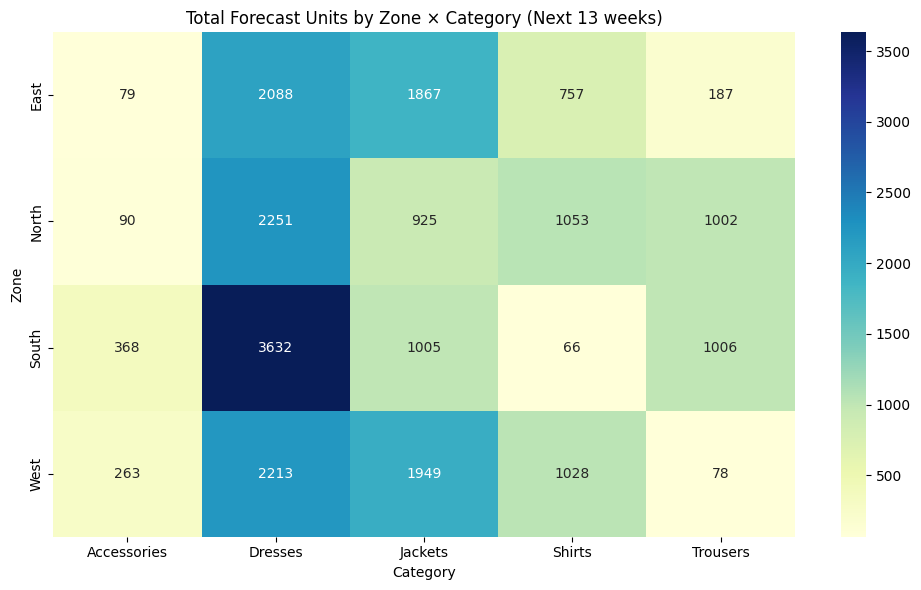

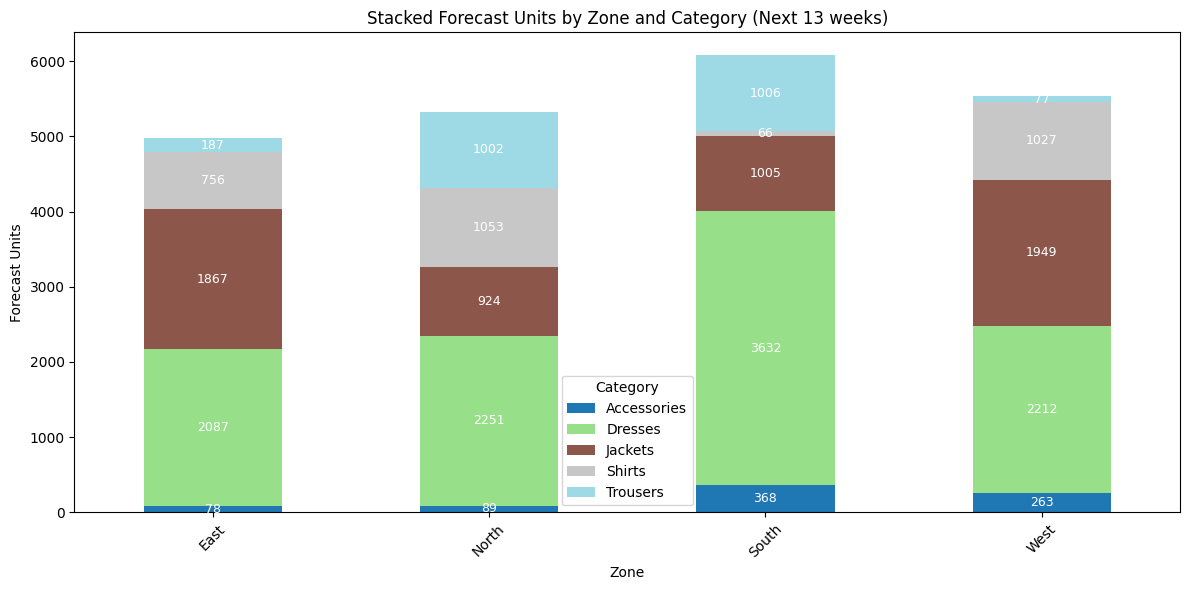

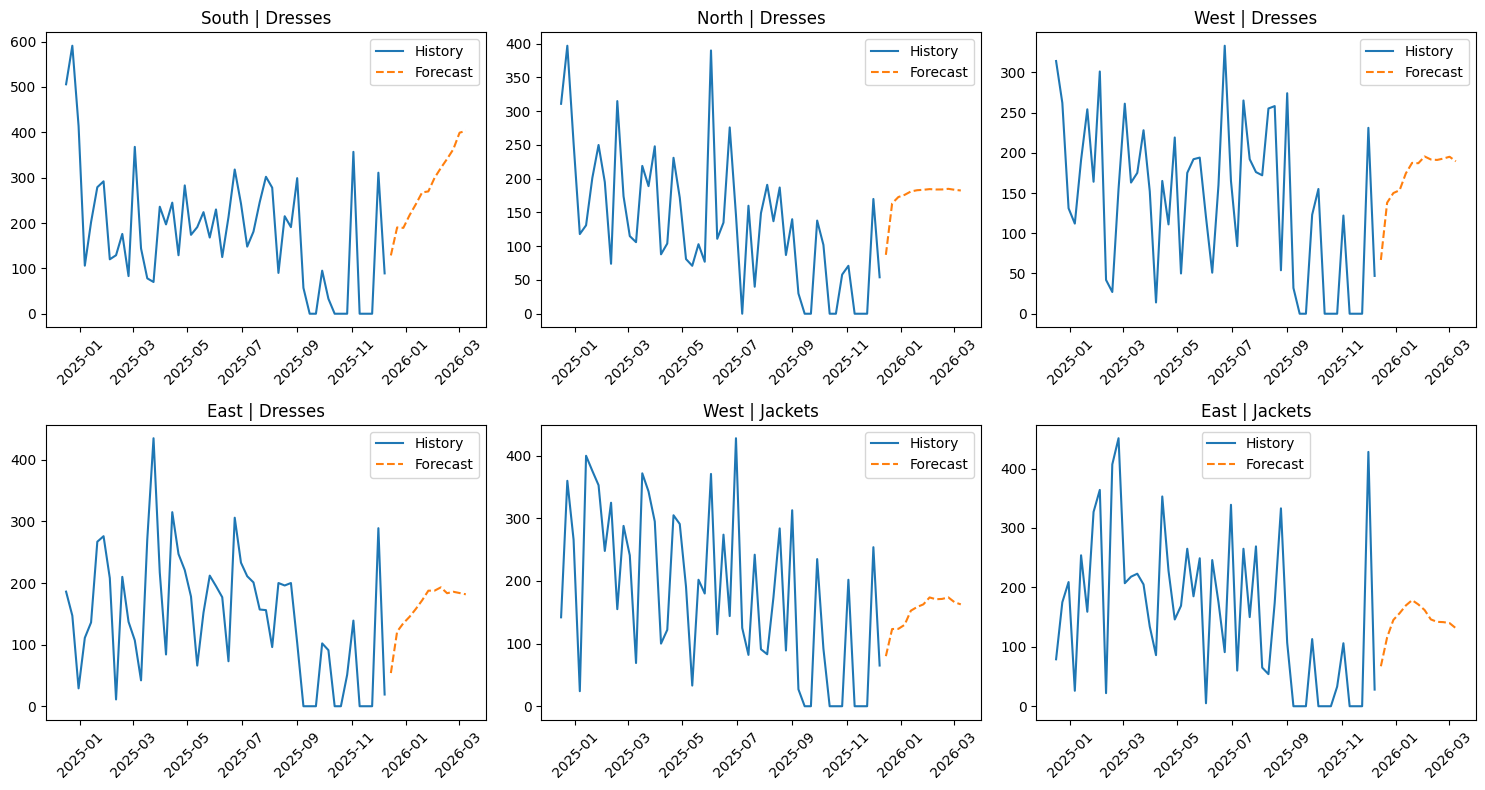

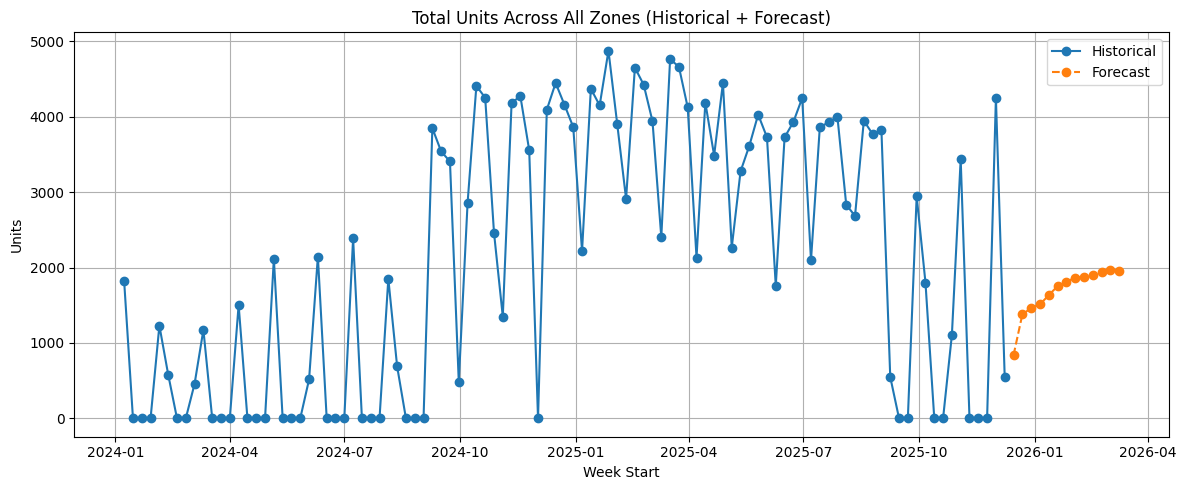


Outputs saved in: C:\Users\saipprad
 - zone_category_forecast_13_weeks.csv exists? True
 - store_category_forecast_13_weeks_base.csv exists? True
 - store_category_forecast_13_weeks_reconciled.csv exists? True


In [16]:
# -------------------------
# Summaries & plots
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns

print('\n--- Quick verification summary ---')
print('Sales date range (daily master):', master['Date'].min(), '->', master['Date'].max())
print('Zone×Category weekly range:', zone_cat_weekly['week_start'].min(), '->', zone_cat_weekly['week_start'].max())
print('Forecast horizon weeks:', len(future_weeks), 'ending at', future_weeks[-1])
print("Model:", model_name, "Val MAE:", round(val_mae,3), "Val RMSE:", round(val_rmse,3))

# -------------------------
# Zone × Category total forecast
# -------------------------
zone_totals_next = zone_forecast_df.groupby(['Zone','Category'])['forecast_units'].sum().reset_index().pivot(index='Zone', columns='Category', values='forecast_units').fillna(0)
print("\nZone x Category total forecast (next {} weeks):".format(HORIZON_WEEKS))
print(zone_totals_next)

# -------------------------
# 1. Heatmap of Zone x Category forecast
# -------------------------
plt.figure(figsize=(10,6))
sns.heatmap(zone_totals_next, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title(f"Total Forecast Units by Zone × Category (Next {HORIZON_WEEKS} weeks)")
plt.ylabel("Zone")
plt.xlabel("Category")
plt.tight_layout()
plt.show()

# -------------------------
# 2. Stacked bar chart by Zone
# -------------------------
ax = zone_totals_next.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title(f"Stacked Forecast Units by Zone and Category (Next {HORIZON_WEEKS} weeks)")
plt.ylabel("Forecast Units")
plt.xlabel("Zone")
plt.xticks(rotation=45)

# Add labels on each stacked segment
for i, zone in enumerate(zone_totals_next.index):
    cum_sum = 0
    for cat in zone_totals_next.columns:
        val = zone_totals_next.loc[zone, cat]
        if val > 0:
            ax.text(i, cum_sum + val/2, int(val), ha='center', va='center', fontsize=9, color='white')
            cum_sum += val

plt.tight_layout()
plt.show()

# -------------------------
# 3. Top N series: combined plots
# -------------------------
try:
    top_pairs = zone_totals_next.stack().sort_values(ascending=False).head(6).reset_index()[['Zone','Category']].values.tolist()
    plt.figure(figsize=(15,8))
    for i, (z,c) in enumerate(top_pairs):
        plt.subplot(2,3,i+1)
        hist = zone_cat_weekly[(zone_cat_weekly['Zone']==z)&(zone_cat_weekly['Category']==c)].set_index('week_start')['units'].tail(52)
        fut = zone_forecast_df[(zone_forecast_df['Zone']==z)&(zone_forecast_df['Category']==c)].set_index('week_start')['forecast_units']
        plt.plot(hist.index, hist.values, label='History')
        plt.plot(fut.index, fut.values, linestyle='--', label='Forecast')
        plt.title(f"{z} | {c}")
        plt.xticks(rotation=45)
        plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Plotting top series failed:', e)

# -------------------------
# 4. Total forecast trend across all zones (historical + forecast)
# -------------------------
# Get historical weekly total
historical_weekly = zone_cat_weekly.groupby('week_start')['units'].sum()
# Get forecast weekly total
forecast_weekly = zone_forecast_df.groupby('week_start')['forecast_units'].sum()

# Combine historical + forecast for smooth continuity
combined = pd.concat([historical_weekly, forecast_weekly[~forecast_weekly.index.isin(historical_weekly.index)]])
plt.figure(figsize=(12,5))
plt.plot(historical_weekly.index, historical_weekly.values, label='Historical', marker='o')
plt.plot(forecast_weekly.index, forecast_weekly.values, label='Forecast', linestyle='--', marker='o')
plt.title("Total Units Across All Zones (Historical + Forecast)")
plt.ylabel("Units")
plt.xlabel("Week Start")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# 5. Save outputs
# -------------------------
print("\nOutputs saved in:", OUT_DIR)
expected = [
    OUT_DIR / f"zone_category_forecast_{HORIZON_WEEKS}_weeks.csv",
    OUT_DIR / f"store_category_forecast_{HORIZON_WEEKS}_weeks_base.csv",
    OUT_DIR / "store_category_forecast_13_weeks_reconciled.csv"
]
for f in expected:
    print(" -", f.name, "exists?", f.exists())


## **Result estimation**

### **Stokcout Forecast (With 50% random replenishment)**

In [19]:
import pandas as pd
import numpy as np

# --------------------------
# Step 1: Load files
# --------------------------
forecast = pd.read_csv('store_category_forecast_13_weeks_reconciled.csv')
inventory = pd.read_excel('Demand Forecasting for Apparel Retail Stores.xlsx', sheet_name='inventory_data')

# --- Fix and standardize date ---
inventory['Date'] = pd.to_datetime(inventory['Date'], dayfirst=False, errors='coerce')
inventory['week_start'] = inventory['Date'] - pd.to_timedelta(inventory['Date'].dt.dayofweek, unit='D')
forecast['week_start'] = pd.to_datetime(forecast['week_start'])

# --------------------------
# Step 2: Compute replenishments from history
# --------------------------
# Replenishment = increase in closing stock week over week
weekly_inv = (
    inventory.groupby(['Store_ID', 'Category', 'week_start'], as_index=False)
    .agg({'Opening_Stock': 'first', 'Closing_Stock': 'last'})
    .sort_values(['Store_ID', 'Category', 'week_start'])
)

weekly_inv['Replenishment'] = weekly_inv.groupby(['Store_ID', 'Category'])['Closing_Stock'].diff()
weekly_inv['Replenishment'] = weekly_inv['Replenishment'].apply(lambda x: x if x > 0 else 0)

# Average replenishment quantity when replenishment > 0
avg_rep = (
    weekly_inv.groupby(['Store_ID', 'Category'], as_index=False)['Replenishment']
    .apply(lambda x: x[x > 0].mean())
    .rename(columns={'Replenishment': 'avg_replenishment'})
)

# --------------------------
# Step 3: Latest stock (start point)
# --------------------------
latest_stock = (
    weekly_inv.sort_values('week_start')
    .groupby(['Store_ID', 'Category'])
    .tail(1)[['Store_ID', 'Category', 'Closing_Stock']]
    .rename(columns={'Closing_Stock': 'Opening_Stock'})
)

# --------------------------
# Step 4: Merge forecast + inventory base
# --------------------------
df = pd.merge(forecast, latest_stock, on=['Store_ID', 'Category'], how='left')
df = pd.merge(df, avg_rep, on=['Store_ID', 'Category'], how='left')

# Fill missing replenishment (in case of NA) with overall mean
df['avg_replenishment'].fillna(df['avg_replenishment'].mean(), inplace=True)

# Sort for simulation
df = df.sort_values(['Store_ID', 'Category', 'week_start']).reset_index(drop=True)

# --------------------------
# Step 5: Simulate future inventory and stockouts
# --------------------------
results = []
for (store, cat), sub in df.groupby(['Store_ID', 'Category']):
    stock = sub['Opening_Stock'].iloc[0]  # starting stock
    avg_rep = sub['avg_replenishment'].iloc[0]
    
    for _, row in sub.iterrows():
        forecast_units = row['forecast_units_reconciled']
        
        # Replenishment rule: assume 50% chance replenishment each week
        replenishment = avg_rep if np.random.rand() < 0.5 else 0
        
        closing_stock = stock - forecast_units + replenishment
        
        stockout = 1 if closing_stock <= 0 else 0
        closing_stock = max(closing_stock, 0)
        
        results.append({
            'Store_ID': store,
            'Category': cat,
            'week_start': row['week_start'],
            'forecast_units': forecast_units,
            'replenishment': replenishment,
            'closing_stock': closing_stock,
            'stockout_flag': stockout
        })
        
        # carry over to next week
        stock = closing_stock

forecasted_stock = pd.DataFrame(results)

# --------------------------
# Step 6: Summary metrics
# --------------------------
summary = forecasted_stock.groupby(['Store_ID', 'Category'], as_index=False).agg({
    'stockout_flag': 'mean',
    'closing_stock': 'mean'
}).rename(columns={'stockout_flag': 'Stockout_Weeks_%', 'closing_stock': 'Avg_Forecasted_Stock'})

print("Forecasted Stockouts Calculated Successfully!")
print(forecasted_stock.head())
print(summary.head())

# Optional: save outputs
forecasted_stock.to_csv('forecasted_stockouts_store_category_week.csv', index=False)
summary.to_csv('forecasted_stockouts_summary.csv', index=False)


Forecasted Stockouts Calculated Successfully!
   Store_ID     Category week_start  forecast_units  replenishment  \
0         1  Accessories 2025-12-15        0.000000     136.487179   
1         1  Accessories 2025-12-22        0.682512       0.000000   
2         1  Accessories 2025-12-29        1.188759     136.487179   
3         1  Accessories 2026-01-05        1.661117       0.000000   
4         1  Accessories 2026-01-12        2.771460       0.000000   

   closing_stock  stockout_flag  
0     575.487179              0  
1     574.804668              0  
2     710.103088              0  
3     708.441970              0  
4     705.670510              0  
   Store_ID     Category  Stockout_Weeks_%  Avg_Forecasted_Stock
0         1  Accessories               0.0            757.390162
1         1      Dresses               0.0            610.697382
2         1      Jackets               0.0            254.258307
3         1       Shirts               0.0           1007.609445
4   

## **Comparison to Historical Stockout**

In [20]:
import pandas as pd

# --------------------------
# Step 1: Load Data
# --------------------------
# Inventory
inventory = pd.read_excel('Demand Forecasting for Apparel Retail Stores.xlsx', sheet_name='inventory_data')
inventory['Date'] = pd.to_datetime(inventory['Date'], dayfirst=False, errors='coerce')
inventory = inventory.dropna(subset=['Date', 'Store_ID', 'Category', 'Stockout'])

# Forecasted stockouts (from your last output file)
forecasted_stock = pd.read_csv('forecasted_stockouts_store_category_week.csv')  # use your saved output
forecasted_stock['week_start'] = pd.to_datetime(forecasted_stock['week_start'])

# --------------------------
# Step 2: Filter historical data to same 13-week horizon
# --------------------------
# Find last 13 weeks in inventory data
latest_date = inventory['Date'].max()
cutoff_date = latest_date - pd.Timedelta(weeks=13)

recent_inv = inventory[inventory['Date'] >= cutoff_date].copy()
recent_inv['week_start'] = recent_inv['Date'] - pd.to_timedelta(recent_inv['Date'].dt.weekday, unit='D')

# Weekly-level stockout (1 if any day in week had stockout)
hist_weekly = (
    recent_inv.groupby(['Store_ID', 'Category', 'week_start'], as_index=False)
    .agg({'Stockout': 'max'})
)

# --------------------------
# Step 3: Calculate historical stockout metrics
# --------------------------
total_weeks_hist = len(hist_weekly)
stockout_weeks_hist = (hist_weekly['Stockout'] == 1).sum()
stockout_weeks_pct_hist = (stockout_weeks_hist / total_weeks_hist) * 100

# --------------------------
# Step 4: Calculate forecasted stockout metrics (already computed)
# --------------------------
total_weeks_fore = len(forecasted_stock)
stockout_weeks_fore = forecasted_stock['stockout_flag'].sum()
stockout_weeks_pct_fore = (stockout_weeks_fore / total_weeks_fore) * 100

# --------------------------
# Step 5: Combine comparison summary
# --------------------------
comparison = pd.DataFrame({
    'Metric': ['Stockout Weeks %', 'Stockout Weeks Count', 'Total Weeks'],
    'Historical (Last 13 Weeks)': [f"{stockout_weeks_pct_hist:.2f}%", stockout_weeks_hist, total_weeks_hist],
    'Forecasted (Next 13 Weeks)': [f"{stockout_weeks_pct_fore:.2f}%", stockout_weeks_fore, total_weeks_fore]
})

print("---------- Stockout Comparison: Historical vs Forecasted ----------")
print(comparison.to_string(index=False))

# --------------------------
# Step 6: Optional - Compare by Category
# --------------------------
hist_cat = (
    hist_weekly.groupby('Category', as_index=False)['Stockout']
    .mean().rename(columns={'Stockout': 'Historical_Stockout_%'})
)
hist_cat['Historical_Stockout_%'] *= 100

fore_cat = (
    forecasted_stock.groupby('Category', as_index=False)['stockout_flag']
    .mean().rename(columns={'stockout_flag': 'Forecasted_Stockout_%'})
)
fore_cat['Forecasted_Stockout_%'] *= 100

cat_comparison = pd.merge(hist_cat, fore_cat, on='Category', how='outer').fillna(0)
print("\n---------- Category-Level Comparison ----------")
print(cat_comparison)


---------- Stockout Comparison: Historical vs Forecasted ----------
              Metric Historical (Last 13 Weeks) Forecasted (Next 13 Weeks)
    Stockout Weeks %                      5.29%                      0.77%
Stockout Weeks Count                         37                         10
         Total Weeks                        700                       1300

---------- Category-Level Comparison ----------
      Category  Historical_Stockout_%  Forecasted_Stockout_%
0  Accessories               6.428571               0.000000
1      Dresses               4.285714               2.692308
2      Jackets               5.000000               0.000000
3       Shirts               5.714286               0.000000
4     Trousers               5.000000               1.153846


## **End**